# Imports

<a href="https://colab.research.google.com/github/sylvainestebe/european-city-inference/blob/main/docs/tutorials/tutorial_1_decision_making.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

# Local project imports
from eci.environment import EnvConfig, Environment
from eci.plots import plot_belief_trajectory, plot_preference
from eci.utils import _extract_env_data_vectorized, get_voter_trajectory_data
from eci.voting_system.beliefs import _get_pref_belief_gap, _get_pref_candidate_gap
from eci.voting_system.decisions import _sample_choice

# Electoral Decision-Making
This tutorial simulates a decision making process where agents (voters) choose between candidates based on their preference and beliefs. The agents reduce the gap between how they think the world is and they want it to be and the candidate that help reduce this gap.

## Setting up the Environment
The environement is made of agent which can be voter or candidate and they get preferences.
First, we initialize the simulation environment. In this example, we create an environement with 1 Voter and 2 Candidates with 2 distinct preference dimensions.

In [2]:
config = EnvConfig(
    num_voters=1,
    num_candidates=4,
    num_preferences=2,
)

In [3]:
env = Environment(config)

You can inspect the agents and get informations about them: Their preferences, if they are candidate or voter and others attributes that will be use in different scenario.

In [4]:
env.agents

[Voter(id=0, preferences={'mean': Array([1.1329739 , 0.07622671], dtype=float32), 'precision': Array([0.7341039 , 0.73211014], dtype=float32)}, tonic_volatility=-1.9997645616531372, budget=100.0, perceived_outcome=None, vote_round_1=[], vote_round_2=[], softmax_probs_1=[], softmax_probs_2=[], dissatisfactions=[], trajectory=None, observation=None),
 Candidate(id=1, policy={'mean': Array([0.5441978, 1.3228855], dtype=float32), 'precision': Array([0.44320548, 0.6147663 ], dtype=float32)}, vote_count=0),
 Candidate(id=2, policy={'mean': Array([1.6109622, 1.3646812], dtype=float32), 'precision': Array([0.79916173, 0.37711793], dtype=float32)}, vote_count=0),
 Candidate(id=3, policy={'mean': Array([1.0930781, 1.5579174], dtype=float32), 'precision': Array([0.6604042, 0.5426362], dtype=float32)}, vote_count=0),
 Candidate(id=4, policy={'mean': Array([0.21519518, 0.7992213 ], dtype=float32), 'precision': Array([0.63282895, 0.38555136], dtype=float32)}, vote_count=0)]

## Visualizing the Agent
You can visualize the agent's internal model. Bottom Nodes ($x_0, x_1$): These represent observations per preference.Top Nodes ($x_2, ...$): These represent the agent's hidden beliefs and preferences.

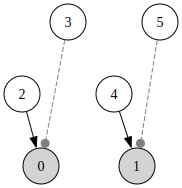

In [5]:
env.network.plot_network()

## Inspecting Preferences
An agent's preference is defined by two parameters: 
**Mean**: The position of the preference
**Precision**: The confidence in that preference.
You can display the preference of your agent, by selecting from the environement which agent you want to plot.

In [6]:
# Get the preference for one agent (preference = (mean,precision)).
env.voters[0].preferences["mean"]
env.voters[0].preferences["precision"]

Array([0.7341039 , 0.73211014], dtype=float32)

We can manually change the preferences to test specific scenarios. Here, we force the Voter to strictly prefer the position [0, 0] (the center) with low precision [0.1, 0.1].

In [7]:
# Modify the preference.
env.voters[0].preferences["mean"] = jnp.array([0, 0])
env.voters[0].preferences["precision"] = jnp.array([0.1, 0.1])
env.voters[0]

Voter(id=0, preferences={'mean': Array([0, 0], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, tonic_volatility=-1.9997645616531372, budget=100.0, perceived_outcome=None, vote_round_1=[], vote_round_2=[], softmax_probs_1=[], softmax_probs_2=[], dissatisfactions=[], trajectory=None, observation=None)

Simultaneously, we position Candidate 1 at [1, 1] and Candidate 2 at [3, 3].

In [8]:
# Modify candidate policy.
env.candidates[0].policy["mean"] = jnp.array([1, 1])
env.candidates[0].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates[1].policy["mean"] = jnp.array([3, 3])
env.candidates[1].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates

[Candidate(id=1, policy={'mean': Array([1, 1], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0),
 Candidate(id=2, policy={'mean': Array([3, 3], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0),
 Candidate(id=3, policy={'mean': Array([1.0930781, 1.5579174], dtype=float32), 'precision': Array([0.6604042, 0.5426362], dtype=float32)}, vote_count=0),
 Candidate(id=4, policy={'mean': Array([0.21519518, 0.7992213 ], dtype=float32), 'precision': Array([0.63282895, 0.38555136], dtype=float32)}, vote_count=0)]

Then you can plot them

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_67536/2578836025.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


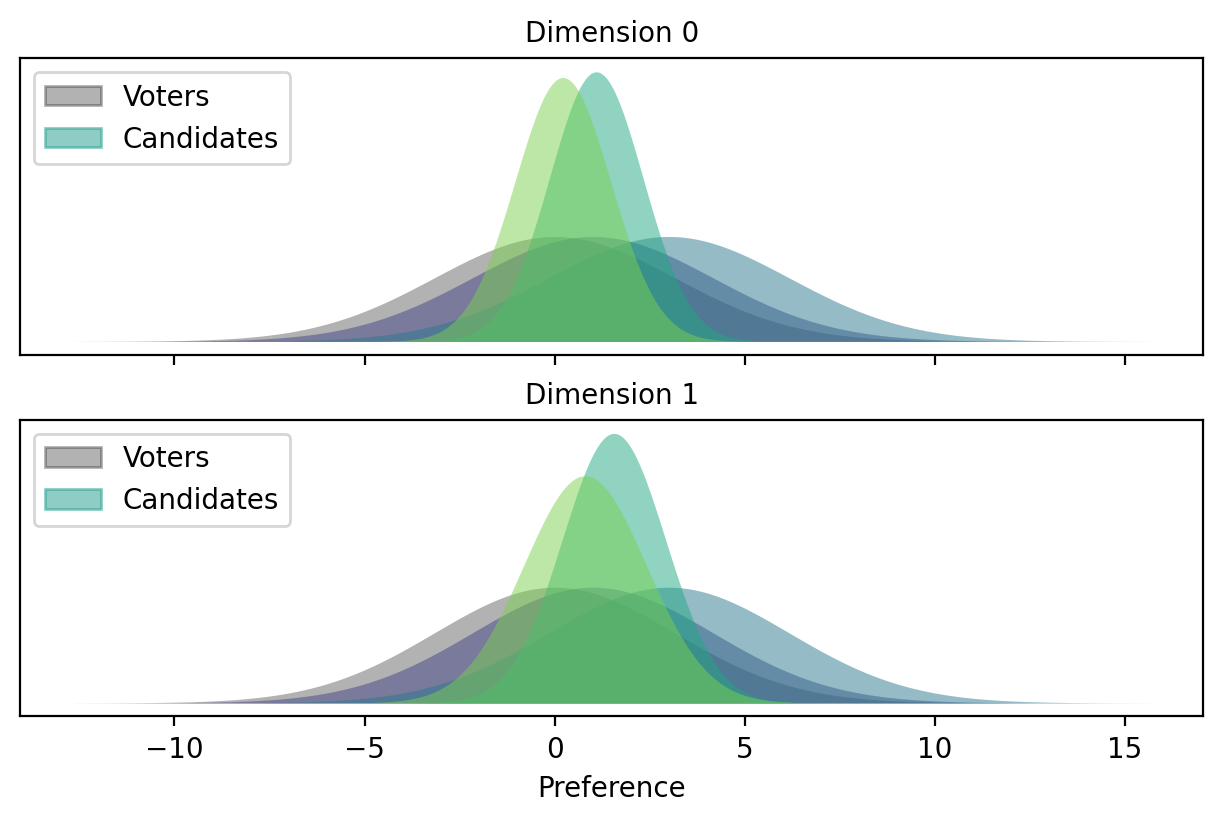

In [9]:
env._run_multi_agent_inference()
fig, ax = plot_preference(env)
fig.show()

## Inspecting Beliefs
For each preference, agent get observation about the world and this contribute to form belief about the world on this specific preference.

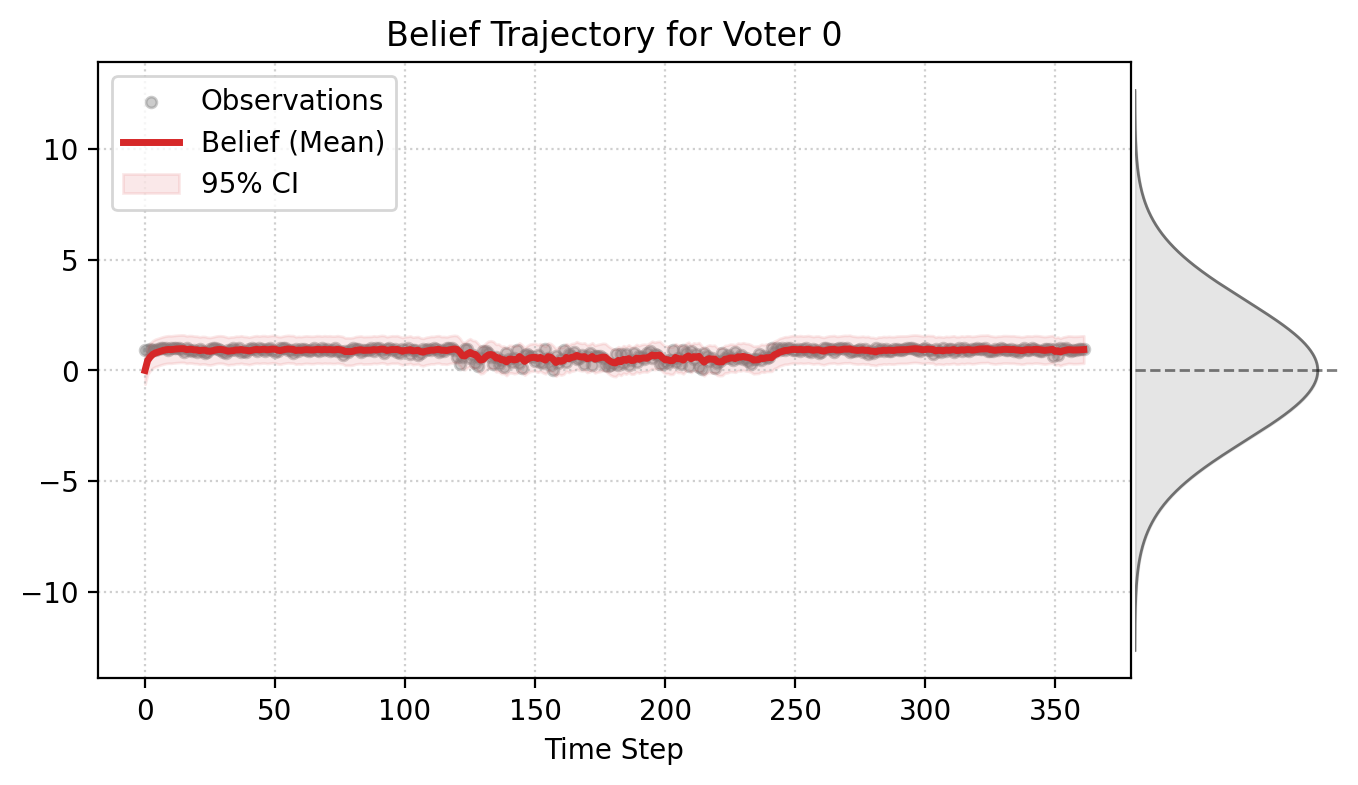

In [10]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

## The Decision Loop
Now that we have defined the agent's beliefs and preferences. The agent must transform its observations into a decision.

This process involves three mathematical steps, executed at every iteration:

In [11]:
# Get the data for all agents.
data = _extract_env_data_vectorized(env)
data

{'beliefs': {'mean': Array([[0.945074  , 0.97748315]], dtype=float32),
  'precision': Array([[8.447314, 8.279185]], dtype=float32)},
 'preferences': {'mean': Array([[0, 0]], dtype=int32),
  'precision': Array([[0.1, 0.1]], dtype=float32)},
 'candidates': {'mean': Array([[1.        , 1.        ],
         [3.        , 3.        ],
         [1.0930781 , 1.5579174 ],
         [0.21519518, 0.7992213 ]], dtype=float32),
  'precision': Array([[0.1       , 0.1       ],
         [0.1       , 0.1       ],
         [0.6604042 , 0.5426362 ],
         [0.63282895, 0.38555136]], dtype=float32)}}

**Calculating the "Gap" (KL Divergence):**
    The agent measures the distance between its *preferences* (what it wants) and its *beliefs* about the world (what it perceives).

In [12]:
pref_belief_gap = _get_pref_belief_gap(data)
pref_belief_gap

Array([85.93381], dtype=float32)

**Calculating the "Gap" (KL Divergence):**
    The agent measures the distance between its *preferences* (what it wants) and the candidate policy.

In [13]:
pref_candidate_gap = _get_pref_candidate_gap(data)
pref_candidate_gap

Array([[0.10000002, 0.9       , 4.2787766 , 2.6324234 ]], dtype=float32)

Then the agent select the candidate that minimize the disatifaction.

In [14]:
candidate_preferences = pref_belief_gap[:, jnp.newaxis] - pref_candidate_gap
candidate_preferences

Array([[85.83381 , 85.033806, 81.65503 , 83.301384]], dtype=float32)

Finally, we randomly select a winner following this probability distribution. This is the final act of voting.

In [15]:
key = jax.random.PRNGKey(int(time.time()))
# Split the JAX key for two separate random samples
key_round_1, key_round_2 = jax.random.split(key)
# Create mask for round 1 (all candidates are eligible)
mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)

# Sample round 1 vote
vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
vote_1

Array([0], dtype=int32)

# Multiple time

We can also do it multiple times

In [16]:
# Do multiple vote for the same agent.
key = jax.random.PRNGKey(int(time.time()))
list_vote = []
num_votes = 100

for i in range(num_votes):
    key, key_iteration = jax.random.split(key)
    key_round_1, key_round_2 = jax.random.split(key_iteration)
    mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
    masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)
    vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
    list_vote.append(vote_1)
list_vote

[Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], 

The graph above displays the distribution of accumulated votes.
Here we can see in the result that the agent mostly vote for the candidate which reduce his disatifaction.

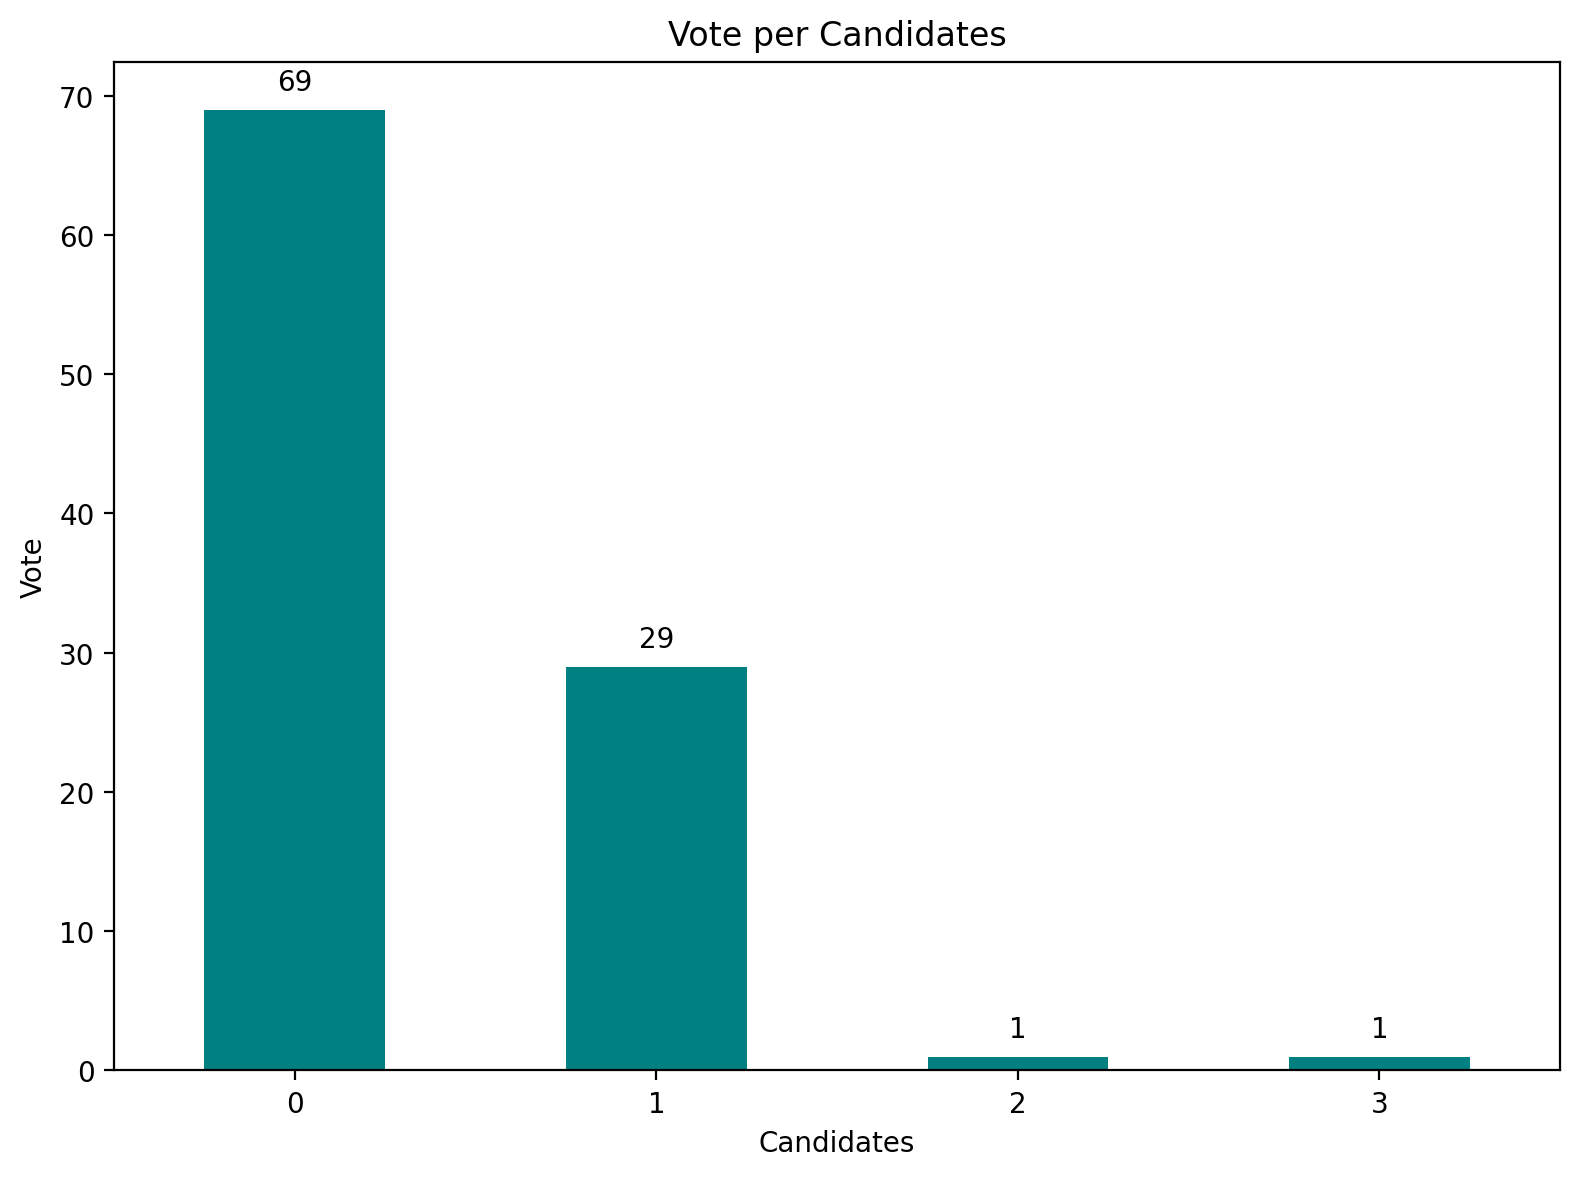

In [17]:
# Plot the votes.
df_votes = pd.DataFrame(list_vote, columns=["Candidat"])
vote_counts = df_votes["Candidat"].value_counts()
plt.figure(figsize=(8, 6))
ax = vote_counts.plot(kind="bar", color="teal")
plt.title("Vote per Candidates")
plt.ylabel("Vote")
plt.xlabel("Candidates")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=5)
plt.tight_layout()

Then we can do it for multiple agent

In [18]:
# 1. Définir la configuration
config = EnvConfig(
    num_voters=3,
    num_candidates=4,
    num_preferences=2,
    # Vous pouvez aussi surcharger les valeurs par défaut ici si besoin :
    # num_steps=362,
    # seed=42
)
NUM_SIMULATIONS = 1  # Number of simulation steps (trajectories)

In [19]:
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS  # Number of simulations

In [20]:
env._run_multi_agent_inference()

In [21]:
data = _extract_env_data_vectorized(env)
data

{'beliefs': {'mean': Array([[0.91668683, 0.9394567 ],
         [0.91668683, 0.9394567 ],
         [0.91668683, 0.9394567 ]], dtype=float32),
  'precision': Array([[8.417332, 8.409484],
         [8.417332, 8.409484],
         [8.417332, 8.409484]], dtype=float32)},
 'preferences': {'mean': Array([[0.7075136, 1.064471 ],
         [0.6990924, 1.919147 ],
         [0.8167114, 1.7302666]], dtype=float32),
  'precision': Array([[0.52354366, 0.5314297 ],
         [0.690339  , 0.715551  ],
         [0.9486269 , 0.51041675]], dtype=float32)},
 'candidates': {'mean': Array([[0.5441978 , 1.3228855 ],
         [1.6109622 , 1.3646812 ],
         [1.0930781 , 1.5579174 ],
         [0.21519518, 0.7992213 ]], dtype=float32),
  'precision': Array([[0.44320548, 0.6147663 ],
         [0.79916173, 0.37711793],
         [0.6604042 , 0.5426362 ],
         [0.63282895, 0.38555136]], dtype=float32)}}

In [22]:
pref_belief_gap = _get_pref_belief_gap(data)
pref_belief_gap

Array([12.431311, 12.725237, 11.853617], dtype=float32)

In [23]:
pref_candidate_gap = _get_pref_candidate_gap(data)
pref_candidate_gap

Array([[0.03857732, 0.42121267, 0.12985069, 0.12303329],
       [0.1626612 , 0.47961444, 0.10462373, 0.396312  ],
       [0.19077742, 0.3049733 , 0.06340176, 0.33550948]], dtype=float32)

In [24]:
preference_score_per_agent = pref_belief_gap[:, jnp.newaxis] - pref_candidate_gap
preference_score_per_agent

Array([[12.392734 , 12.0100975, 12.30146  , 12.308277 ],
       [12.562575 , 12.245623 , 12.620613 , 12.328925 ],
       [11.662839 , 11.548643 , 11.790215 , 11.518107 ]], dtype=float32)